# Linear Regression

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from word2number import w2n

In [2]:
df = pd.read_csv('home_price_train.csv')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


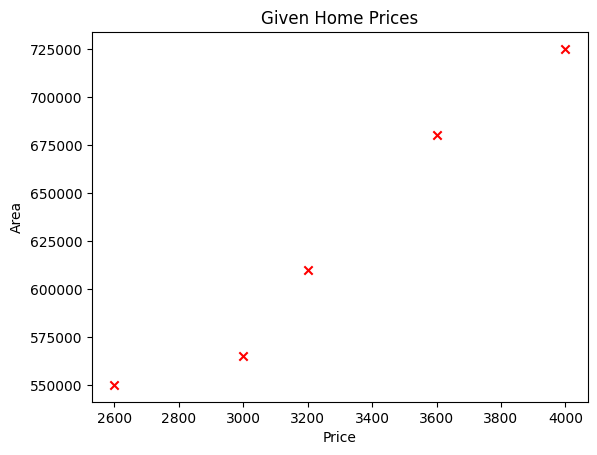

In [3]:
plt.title('Given Home Prices')
plt.xlabel('Price')
plt.ylabel('Area')
plt.scatter(df.area, df.price, marker = 'x', color='red')

In [4]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']], df['price'])

LinearRegression()

In [5]:
reg.predict([[3300]])

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

Text(0.5, 1.0, 'Linear Regression Model')

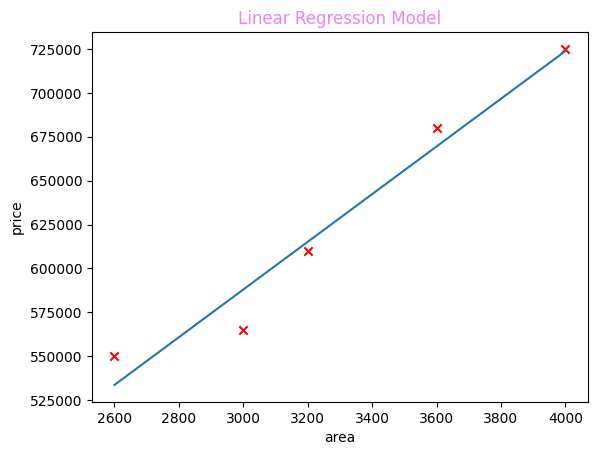

In [6]:
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area, df.price, marker='x', color = 'red')
plt.plot(df.area, reg.predict(df[['area']]))
plt.title('Linear Regression Model', color = 'violet')

In [7]:
# y = mx + c
# price = slope * area + intercept
 
m = reg.coef_
c = reg.intercept_

price = m * 3300 + c
print(price)
print(reg.predict([[3300]]))

[628715.75342466]
[628715.75342466]


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
df_areas = pd.read_csv('areas.csv')
df_areas

,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [9]:
prices = reg.predict(df_areas[['area']])
prices

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [10]:
df_areas['price'] = np.round(prices, 2)
df_areas

,area,price
0,1000,316404.11
1,1500,384297.95
2,2300,492928.08
3,3540,661304.79
4,4120,740061.64
5,4560,799808.22
6,5490,926090.75
7,3460,650441.78
8,4750,825607.88
9,2300,492928.08


In [11]:
df_areas.to_csv('areas.csv', index = False)

In [12]:
reg.predict([[2600]])

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([533664.38356164])

## Canada Per Capita Model

In [14]:
canada = pd.read_csv('canada_per_capita.csv', names=['year', 'income'], skiprows = 1)
canada

,year,income
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


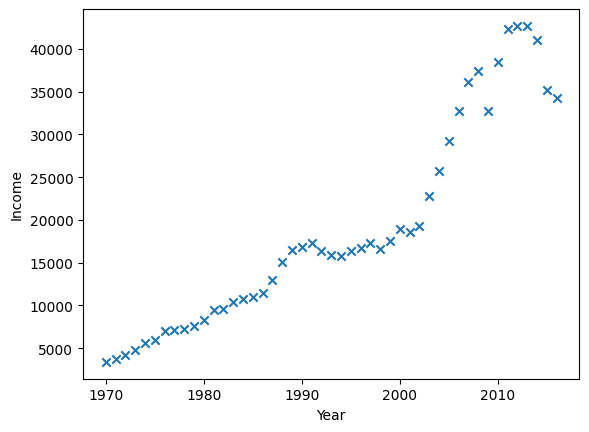

In [15]:
plt.xlabel('Year')
plt.ylabel('Income')
plt.scatter(canada.year, canada.income, marker='x')

In [16]:
reg_canada = linear_model.LinearRegression()
reg_canada.fit(canada[['year']], canada['income'])

LinearRegression()

In [27]:
reg_canada.predict([[2030]])

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([49573.34484664])

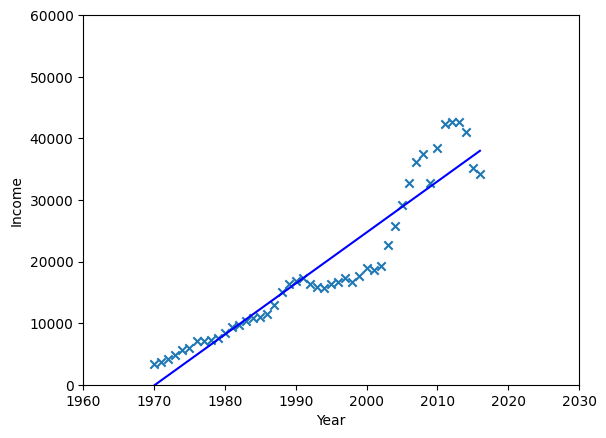

In [28]:
plt.xlabel('Year')
plt.ylabel('Income')
plt.xlim((1960,2030))
plt.ylim((0,60000))
plt.scatter(canada.year, canada.income, marker='x')
plt.plot(canada.year, reg_canada.predict(canada[['year']]), color = 'blue')

# Multivariate Linear Regression

In [41]:
df = pd.read_csv('home_price_multi.csv')
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [44]:
median_bedrooms = df.bedrooms.median()
df.bedrooms = df.bedrooms.fillna(median_bedrooms)
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [45]:
reg = linear_model.LinearRegression()
reg.fit(df[['area', 'bedrooms', 'age']], df.price)

LinearRegression()

In [55]:
reg.predict([[3000, 3, 40]])

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

#### y = m1x1 + m2x2 + m3x3 + c
#### price = m1 * area + m2 * bedrooms + m3 * age + intercept

In [56]:
m = reg.coef_
c = reg.intercept_
price = m[0] * 3000 + m[1] * 3 + m[2] * 40 + c
print(price)

498408.2515803069


In [60]:
m = reg.coef_
c = reg.intercept_
print('m =', m ,'\nc =', c)

m = [  112.06244194 23388.88007794 -3231.71790863] 
c = 221323.00186540443


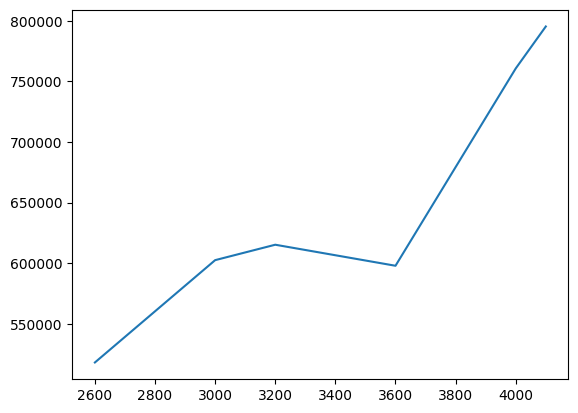

In [64]:
plt.plot(df[['area']], reg.predict(df[['area', 'bedrooms', 'age']]))

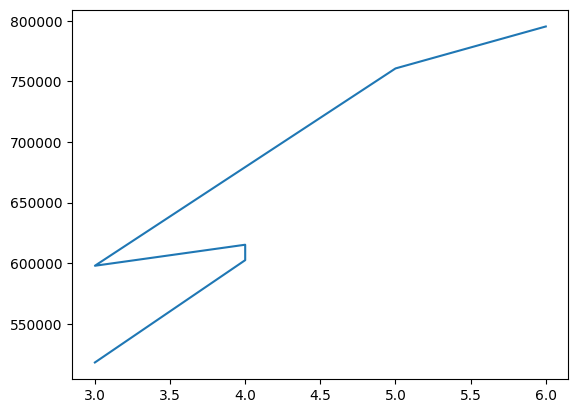

In [73]:
plt.plot(df[['bedrooms']], reg.predict(df[['area', 'bedrooms', 'age']]))

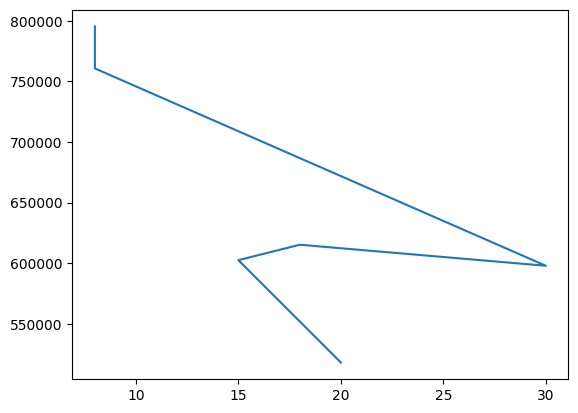

In [68]:
plt.plot(df[['age']], reg.predict(df[['area', 'bedrooms', 'age']]))

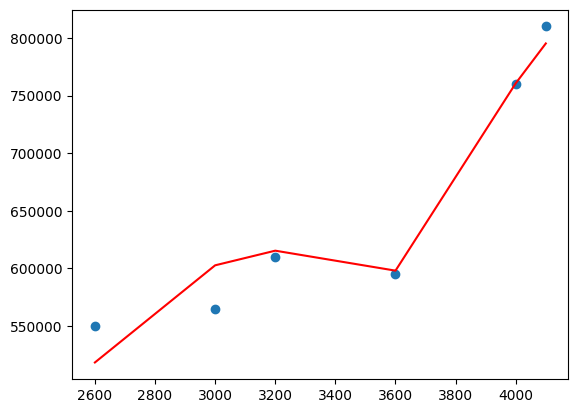

In [72]:
plt.scatter(df[['area']], df.price)
plt.plot(df[['area']], reg.predict(df[['area', 'bedrooms', 'age']]), color='red')

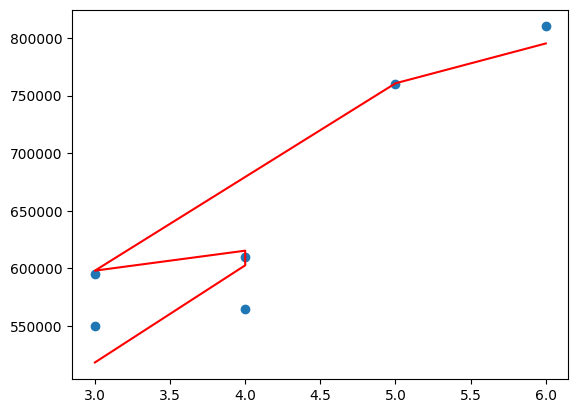

In [75]:
plt.plot(df[['bedrooms']], reg.predict(df[['area', 'bedrooms', 'age']]), color = 'red')
plt.scatter(df[['bedrooms']], df.price)

### hiring.csv dataset

In [185]:
hiring = pd.read_csv('hiring.csv', names=['exp', 'test_score', 'interview_score', 'salary'], skiprows = 1)
hiring

,exp,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [186]:
hiring.test_score = hiring.test_score.fillna(hiring.test_score.median())
hiring

,exp,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [187]:
type(hiring['exp'][3])

str

In [189]:
hiring.exp.fillna('zero', inplace=True)

In [190]:
hiring

,exp,test_score,interview_score,salary
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [191]:
hiring.exp = hiring.exp.apply(w2n.word_to_num)

In [192]:
hiring

,exp,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [193]:
reg = linear_model.LinearRegression()
reg.fit(hiring[['exp', 'test_score', 'interview_score']], hiring.salary)

LinearRegression()

In [194]:
reg.predict([[2,9,6]])

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53205.96797671])